##### Setup

###### Imports

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from svipy.normflow import inverseAutoRegressiveFlow, maskedAutoRegressiveFlow, normFlowSequential, normFlowPriorNormal, normFlowPosterior
from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


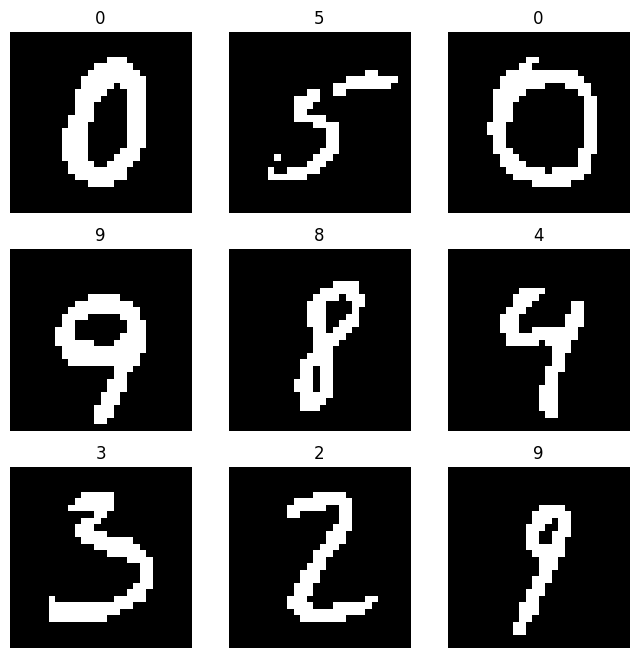

In [4]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


In [6]:
def activeUnits(model, dataset, threshold=0.01, batchSize=256, device=device):
    """
    Burda et al.'s "active units" statistic: Var_x[mu(x)] per latent
    dimension, computed across the dataset. A dimension whose posterior
    mean barely moves across different inputs is \"dead\" -- carrying no
    information about x, regardless of what its logVar looks like.
    """
    
    model.eval()
    loader = DataLoader(dataset, batch_size=batchSize, shuffle=False)
    means = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            zMean, _ = model.encode(data)
            means.append(zMean.cpu())
    means = torch.cat(means, dim=0)
    
    variance = means.var(dim=0)
    nActive = 0
    for i, v in enumerate(variance):
        active = v.item() > threshold
        nActive += active
        print(f"dim {i}: Var_x[mu] = {v.item():.6f}  ({'active' if active else 'DEAD'})")
    
    print(f"{nActive}/{len(variance)} active units (threshold={threshold})")          
    return variance

##### VAEs with norm flows

In [7]:
class sumBceDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

###### Masked autoregressive flows

In [8]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

prior = normFlowPriorNormal(normFlowSequential(OrderedDict([('maf1', maskedAutoRegressiveFlow([16, 256, 256])),
                                                            ('maf2', maskedAutoRegressiveFlow([16, 256, 256])),
                                                            ('maf3', maskedAutoRegressiveFlow([16, 256, 256]))
                                                           ])), hid_dims)

model_vae_maf = variationalAutoencoder(encoder, decoder, prior=prior).to(device)

In [9]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_maf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [10]:
%%time 
model_vae_maf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_maf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 208.206711 reconLoss: 207.009857 klLoss: 1.196853[12800/60000]
totalLoss: 193.701279 reconLoss: 191.922821 klLoss: 1.778458[25600/60000]
totalLoss: 184.506653 reconLoss: 181.287933 klLoss: 3.218722[38400/60000]
totalLoss: 175.640747 reconLoss: 170.873627 klLoss: 4.767117[51200/60000]
Validation Error: 167.715529
Epoch 2
-------------------------------
totalLoss: 165.016861 reconLoss: 157.983887 klLoss: 7.032976[12800/60000]
totalLoss: 154.519333 reconLoss: 147.071762 klLoss: 7.447574[25600/60000]
totalLoss: 150.320038 reconLoss: 142.384583 klLoss: 7.935448[38400/60000]
totalLoss: 146.882141 reconLoss: 137.462021 klLoss: 9.420115[51200/60000]
Validation Error: 142.651580
Epoch 3
-------------------------------
totalLoss: 144.001816 reconLoss: 133.795013 klLoss: 10.206802[12800/60000]
totalLoss: 130.912567 reconLoss: 120.625931 klLoss: 10.286638[25600/60000]
totalLoss: 133.656616 reconLoss: 122.608757 klLoss: 11.047853[38400/60000]
total

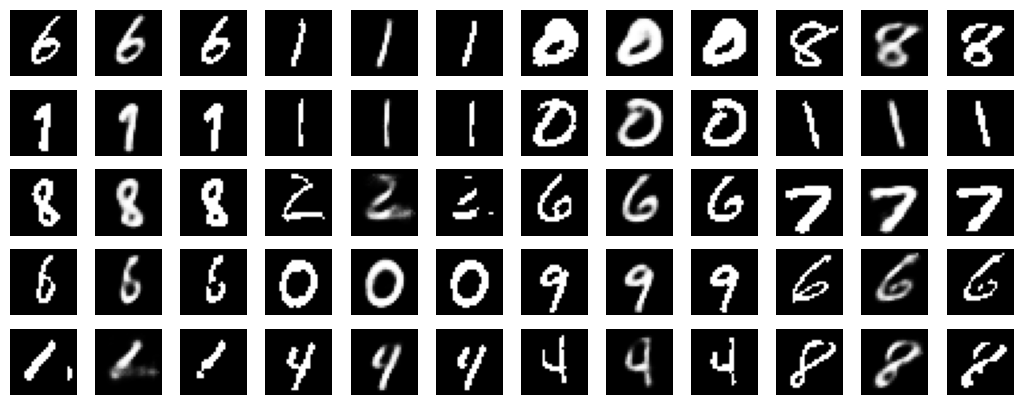

In [11]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_maf.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_maf.decode(model_vae_maf.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [12]:
activeUnits(model_vae_maf, trainImageData)

dim 0: Var_x[mu] = 11.632674  (active)
dim 1: Var_x[mu] = 22.646273  (active)
dim 2: Var_x[mu] = 11.823812  (active)
dim 3: Var_x[mu] = 16.614342  (active)
dim 4: Var_x[mu] = 20.731810  (active)
dim 5: Var_x[mu] = 14.016336  (active)
dim 6: Var_x[mu] = 11.595230  (active)
dim 7: Var_x[mu] = 15.084675  (active)
dim 8: Var_x[mu] = 18.922062  (active)
dim 9: Var_x[mu] = 26.657814  (active)
dim 10: Var_x[mu] = 14.089952  (active)
dim 11: Var_x[mu] = 10.844925  (active)
dim 12: Var_x[mu] = 16.684181  (active)
dim 13: Var_x[mu] = 17.904200  (active)
dim 14: Var_x[mu] = 13.032881  (active)
dim 15: Var_x[mu] = 15.267439  (active)
16/16 active units (threshold=0.01)


tensor([11.6327, 22.6463, 11.8238, 16.6143, 20.7318, 14.0163, 11.5952, 15.0847,
        18.9221, 26.6578, 14.0900, 10.8449, 16.6842, 17.9042, 13.0329, 15.2674])

###### Inverse Autoregressive Flows

In [14]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)


posterior = normFlowPosterior(normFlowSequential(OrderedDict([('iaf1', inverseAutoRegressiveFlow([16, 16, 16])),
                                                              ('iaf2', inverseAutoRegressiveFlow([16, 16, 16])),
                                                              ('iaf3', inverseAutoRegressiveFlow([16, 16, 16]))
                                                             ])), hid_dims)

model_vae_iaf = variationalAutoencoder(encoder, decoder, posterior=posterior).to(device)

In [15]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_iaf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [16]:
%%time 
model_vae_iaf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_iaf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 157.420532 reconLoss: 202.626892 klLoss: -45.206360[12800/60000]
totalLoss: 143.477264 reconLoss: 198.156647 klLoss: -54.679375[25600/60000]
totalLoss: 125.967461 reconLoss: 193.097626 klLoss: -67.130165[38400/60000]
totalLoss: 111.169693 reconLoss: 196.586578 klLoss: -85.416885[51200/60000]
Validation Error: 83.163112
Epoch 2
-------------------------------
totalLoss: 57.229919 reconLoss: 167.614594 klLoss: -110.384674[12800/60000]
totalLoss: 36.180748 reconLoss: 151.042465 klLoss: -114.861717[25600/60000]
totalLoss: 25.056381 reconLoss: 151.064346 klLoss: -126.007965[38400/60000]
totalLoss: 13.862137 reconLoss: 144.907867 klLoss: -131.045731[51200/60000]
Validation Error: 17.635486
Epoch 3
-------------------------------
totalLoss: 6.573257 reconLoss: 141.298676 klLoss: -134.725418[12800/60000]


KeyboardInterrupt: 

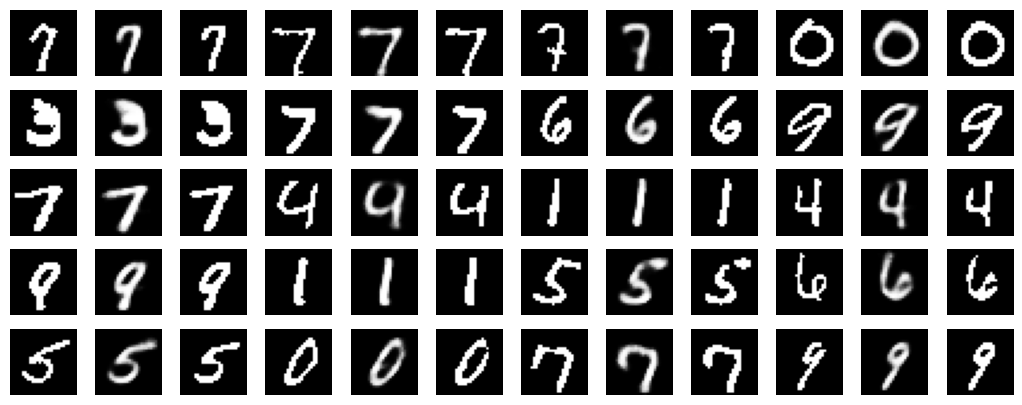

In [16]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_iaf.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_iaf.decode(model_vae_iaf.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [17]:
activeUnits(model_vae_iaf, trainImageData)

dim 0: Var_x[mu] = 36.672474  (active)
dim 1: Var_x[mu] = 3.502853  (active)
dim 2: Var_x[mu] = 42.426277  (active)
dim 3: Var_x[mu] = 42.258625  (active)
dim 4: Var_x[mu] = 14.906308  (active)
dim 5: Var_x[mu] = 25.456034  (active)
dim 6: Var_x[mu] = 11.488478  (active)
dim 7: Var_x[mu] = 9.593101  (active)
dim 8: Var_x[mu] = 20.794315  (active)
dim 9: Var_x[mu] = 0.312040  (active)
dim 10: Var_x[mu] = 3.482134  (active)
dim 11: Var_x[mu] = 7.190479  (active)
dim 12: Var_x[mu] = 4.691141  (active)
dim 13: Var_x[mu] = 4.396344  (active)
dim 14: Var_x[mu] = 8.734289  (active)
dim 15: Var_x[mu] = 4.955339  (active)
16/16 active units (threshold=0.01)


tensor([36.6725,  3.5029, 42.4263, 42.2586, 14.9063, 25.4560, 11.4885,  9.5931,
        20.7943,  0.3120,  3.4821,  7.1905,  4.6911,  4.3963,  8.7343,  4.9553])